In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set seaborn style
sns.set_style('whitegrid')

# Read CSV file
df = pd.read_csv(r'C:\Users\shaan\OneDrive\Desktop\Project 3\retail_large_dataset.csv')

# Display first 5 rows
df.head()

# Display information about dataset
df.info()

# Display descriptive statistics
df.describe(include='all')

# Check missing values
df.isnull().sum()

# Check duplicate rows
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

np.int64(0)

Data preparation

In [7]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Derive time-based columns for grouping
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.month_name()
df['day_of_week'] = df['order_date'].dt.day_name()

# Encode return_status as binary flag for correlation/numeric analysis
df['return_flag'] = df['return_status'].map({'No': 0, 'Yes': 1})

# Quick check
df[['order_date', 'order_year', 'order_month', 'order_month_name', 'day_of_week', 'return_status', 'return_flag']].head()

,order_date,order_year,order_month,order_month_name,day_of_week,return_status,return_flag
0,2025-05-10,2025,5,May,Saturday,No,0
1,2023-11-27,2023,11,November,Monday,Yes,1
2,2025-02-08,2025,2,February,Saturday,No,0
3,2024-04-19,2024,4,April,Friday,No,0
4,2024-10-08,2024,10,October,Tuesday,No,0


 Univariate Analysis: Numerical Variables 


In [11]:
num_cols = ['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days']

summary_stats = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std_Dev': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
})

summary_stats = summary_stats.round(2)
summary_stats

,Mean,Median,Std_Dev,Min,Max,Skewness,Kurtosis
age,41.56,42.00,13.85,18.0,65.0,-0.00,-1.20
product_price,30164.53,30148.00,17139.68,500.0,59998.0,0.00,-1.20
quantity,2.50,3.00,1.12,1.0,4.0,-0.00,-1.36
discount_percentage,15.01,15.00,8.95,0.0,30.0,-0.00,-1.20
final_price,64165.72,49752.39,49969.28,357.0,239980.0,0.93,0.17
delivery_days,5.51,5.00,2.87,1.0,10.0,0.00,-1.22


Outlier detection

age Skew: -0.004987845917701184 Kurtosis: -1.2011722322855403


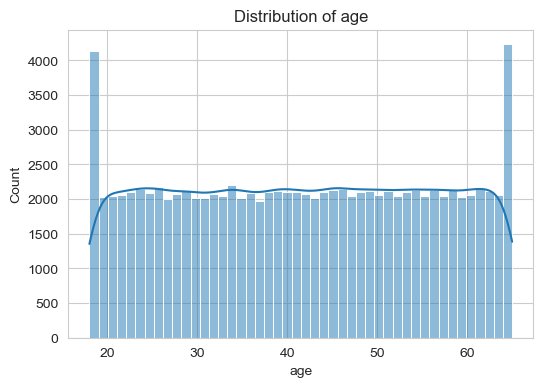

product_price Skew: 0.0032490380525730346 Kurtosis: -1.1951055614421242


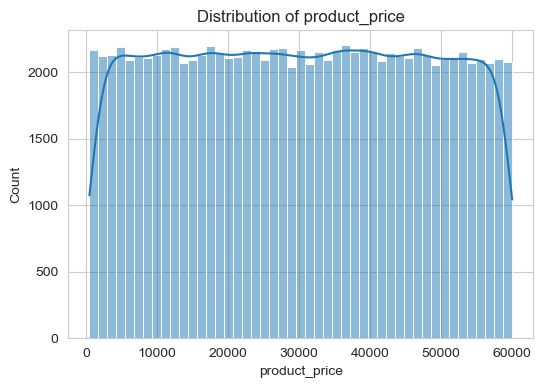

quantity Skew: -0.0030668644828606632 Kurtosis: -1.3646120730484137


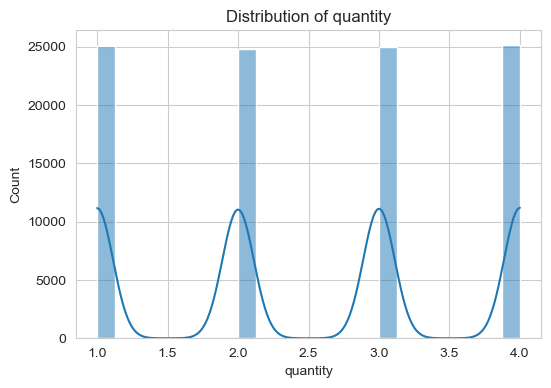

discount_percentage Skew: -0.0035969368284452896 Kurtosis: -1.2016281010376046


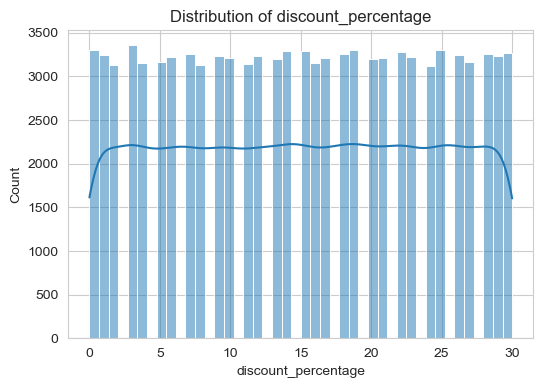

final_price Skew: 0.9347465430576104 Kurtosis: 0.16904721381804322


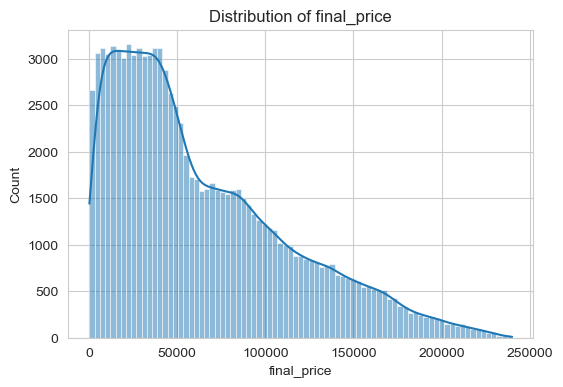

delivery_days Skew: 0.002269710988476146 Kurtosis: -1.2215141919683516


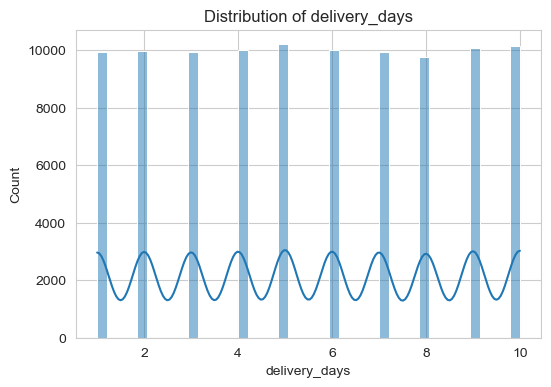

In [12]:
num_cols = ['age','product_price','quantity','discount_percentage','final_price','delivery_days']
df[num_cols].describe()
for col in num_cols:
    print(col, 'Skew:', df[col].skew(), 'Kurtosis:', df[col].kurt())
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

Bivariate: numerical vs categorical

gender
Male      50.111
Female    49.889
Name: proportion, dtype: float64


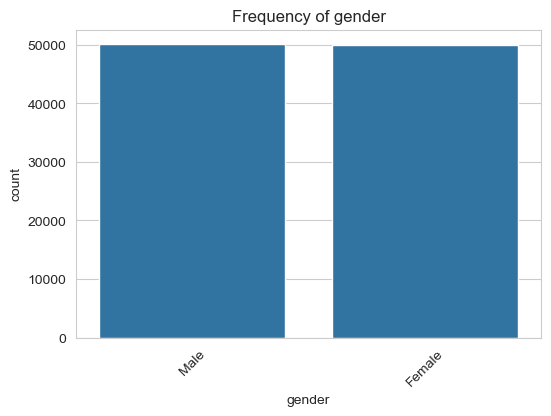

customer_segment
New        33.488
Regular    33.361
Premium    33.151
Name: proportion, dtype: float64


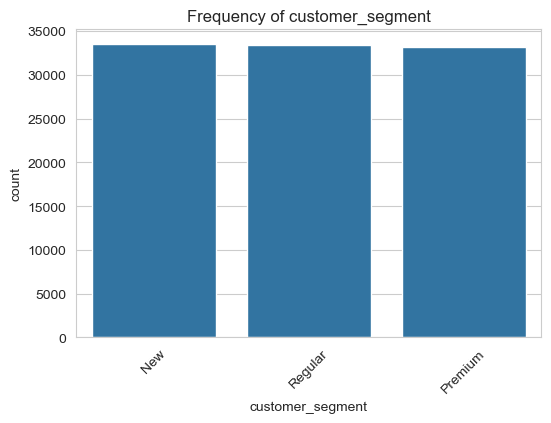

product_category
Health            16.858
Home & Kitchen    16.848
Fashion           16.613
Grocery           16.592
Electronics       16.576
Beauty            16.513
Name: proportion, dtype: float64


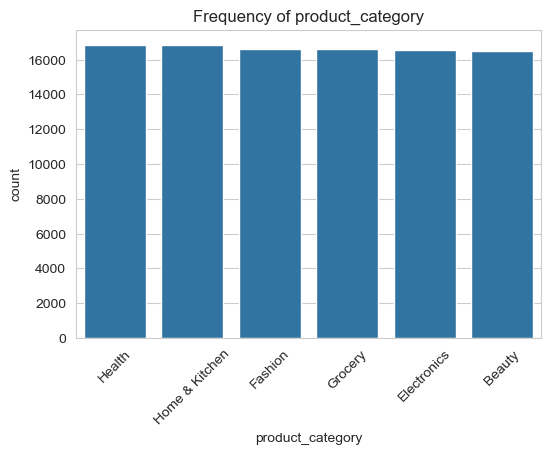

payment_method
Credit Card         25.307
UPI                 25.139
Cash on Delivery    24.994
Debit Card          24.560
Name: proportion, dtype: float64


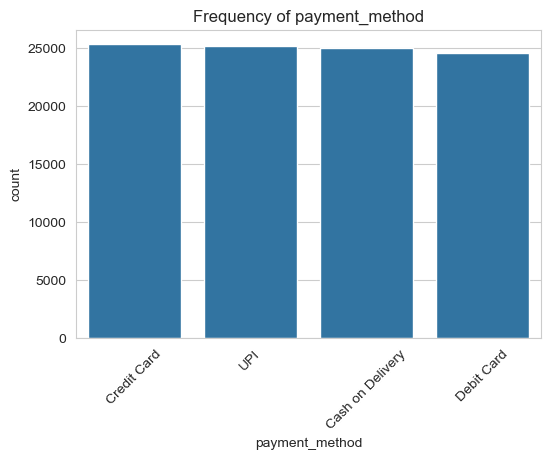

shipping_type
Express     50.008
Standard    49.992
Name: proportion, dtype: float64


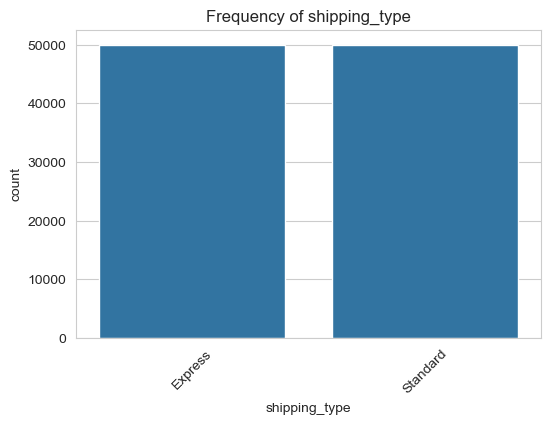

return_status
No     85.189
Yes    14.811
Name: proportion, dtype: float64


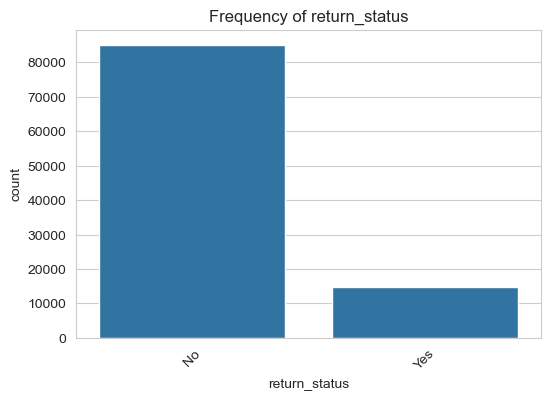

In [14]:
cat_cols = ['gender','customer_segment','product_category','payment_method','shipping_type','return_status']
for col in cat_cols:
    print(df[col].value_counts(normalize=True)*100)
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Frequency of {col}')
    plt.show()

Correlation matrix / heatmap

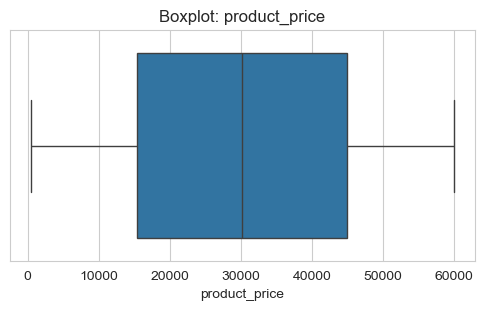

product_price IQR outliers: 0
product_price Z-score outliers: 0


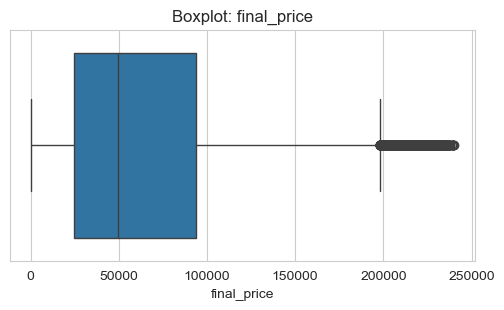

final_price IQR outliers: 1335
final_price Z-score outliers: 503


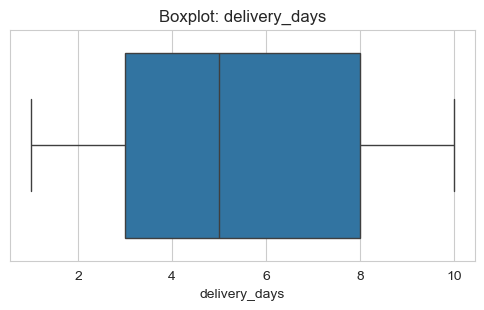

delivery_days IQR outliers: 0
delivery_days Z-score outliers: 0


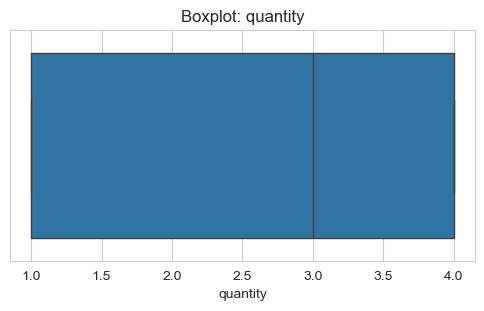

quantity IQR outliers: 0
quantity Z-score outliers: 0


In [15]:
for col in ['product_price','final_price','delivery_days','quantity']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

    Q1, Q3 = df[col].quantile([0.25,0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers_iqr = df[(df[col]<lower)|(df[col]>upper)]
    print(col, 'IQR outliers:', len(outliers_iqr))

    z_scores = np.abs(stats.zscore(df[col]))
    print(col, 'Z-score outliers:', (z_scores>3).sum())

Multivariate analysis

               product_price  final_price
product_price       1.000000     0.730757
final_price         0.730757     1.000000


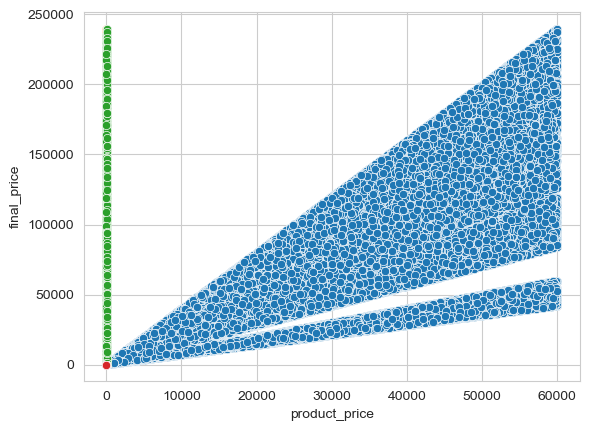

In [16]:
sns.scatterplot(data=df, x='product_price', y='final_price')
sns.scatterplot(data=df, x='quantity', y='final_price')
sns.scatterplot(data=df, x='age', y='final_price')
sns.scatterplot(data=df, x='delivery_days', y='return_flag')

print(df[['product_price','final_price']].corr())

Correlation Analysis of Customer Data

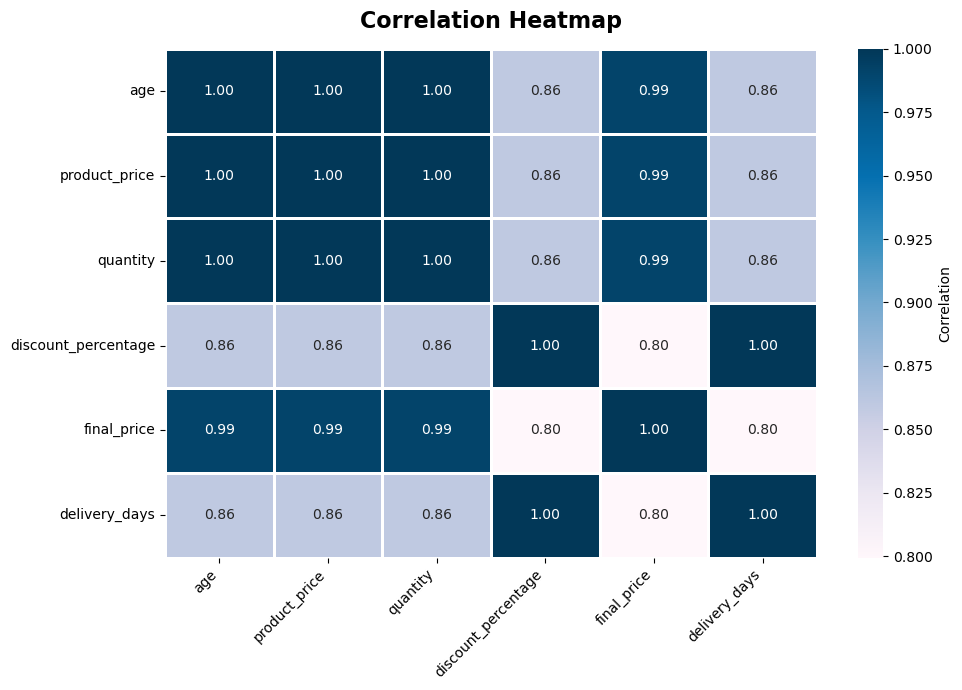

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame
df = pd.DataFrame({
    'age': [20, 25, 30, 35, 40, 45, 50],
    'product_price': [100, 200, 300, 400, 500, 600, 700],
    'quantity': [1, 2, 3, 4, 5, 6, 7],
    'discount_percentage': [5, 10, 15, 10, 20, 15, 25],
    'final_price': [95, 180, 255, 360, 400, 510, 525],
    'delivery_days': [2, 3, 4, 3, 5, 4, 6]
})

# Select numeric columns
num_cols = df.select_dtypes(include='number').columns.tolist()

# Correlation matrix
corr = df[num_cols].corr()

# Professional heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='PuBu',
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Correlation'}
)

plt.title(
    'Correlation Heatmap',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Average spending by customer segment & age group

Average Final Price by Customer Segment and Age Group:
age_group         (18, 30]  (30, 45]  (45, 60]  (60, 100]
customer_segment                                         
New               63976.10  63894.92  63646.73   63403.57
Premium           63826.52  64916.98  64329.23   64476.87
Regular           63899.96  64284.07  64381.63   64674.23


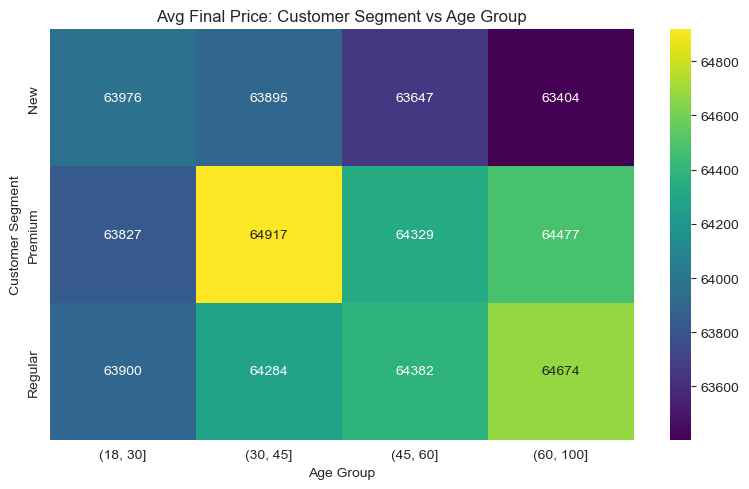

In [19]:
# 2. Customer Segment x Age Group x Spending
df['age_group'] = pd.cut(df['age'], bins=[18,30,45,60,100])

pivot2 = df.pivot_table(
    values='final_price',
    index='customer_segment',
    columns='age_group',
    aggfunc='mean',
    observed=False
)

print("Average Final Price by Customer Segment and Age Group:")
print(pivot2.round(2))

plt.figure(figsize=(8,5))
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='viridis')
plt.title('Avg Final Price: Customer Segment vs Age Group')
plt.xlabel('Age Group')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

Return Rate Analysis by Shipping Type and Delivery Duration

Return Rate by Shipping Type and Delivery Days Bucket:
delivery_days  (0.991, 3.25]  (3.25, 5.5]  (5.5, 7.75]  (7.75, 10.0]
shipping_type                                                       
Express                0.148        0.148        0.153         0.148
Standard               0.148        0.144        0.147         0.149


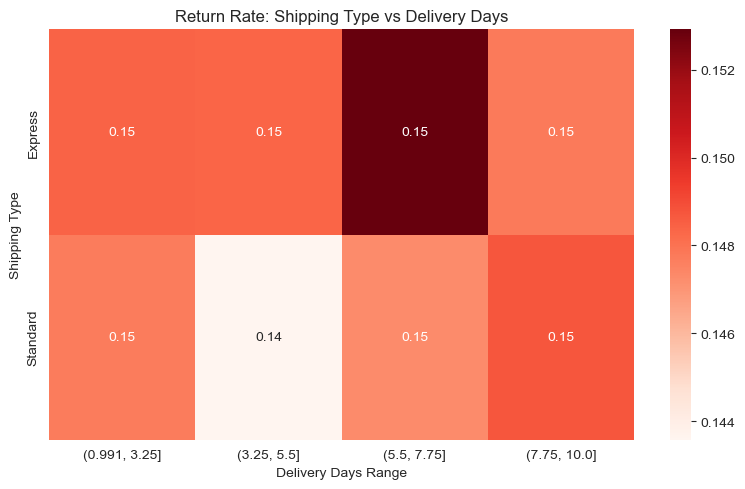

In [8]:
#Shipping Type x Delivery Days x Return Rate
pivot3 = df.pivot_table(
    values='return_flag',
    index='shipping_type',
    columns=pd.cut(df['delivery_days'], bins=4),
    aggfunc='mean',
    observed=False
)

print("Return Rate by Shipping Type and Delivery Days Bucket:")
print(pivot3.round(3))

plt.figure(figsize=(8,5))
sns.heatmap(pivot3, annot=True, fmt='.2f', cmap='Reds')
plt.title('Return Rate: Shipping Type vs Delivery Days')
plt.xlabel('Delivery Days Range')
plt.ylabel('Shipping Type')
plt.tight_layout()
plt.show()